# Présentation de l'étude de cas

# Traitement de l'étude de cas

L'objectif de ce dataset est d'utiliser ces caractéristiques pour prédire si une flamme sera éteinte ou non en fonction des paramètres de l'expérience, ce qui en fait un problème de classification.

## Pretraitement

### Chargement des données

In [258]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [259]:
import pandas as pd
observations=pd.read_excel('/content/drive/MyDrive/Dataset ML/Acoustic_Extinguisher_Fire_Dataset.xlsx')

# Afficher quelques lignes pour confirmer que le chargement est correct
observations.head(5)

,SIZE,FUEL,DISTANCE,DESIBEL,AIRFLOW,FREQUENCY,STATUS
0,1,gasoline,10,96,0.0,75,0
1,1,gasoline,10,96,0.0,72,1
2,1,gasoline,10,96,2.6,70,1
3,1,gasoline,10,96,3.2,68,1
4,1,gasoline,10,109,4.5,67,1


### Exploration des données

In [273]:
#Afficher l'intitulé des différentes colonnes
print(observations.columns.values)

# Afficher la dimension du dataset
print(observations.shape)

['SIZE' 'FUEL' 'DISTANCE' 'DESIBEL' 'AIRFLOW' 'FREQUENCY' 'STATUS']
(17442, 7)


Notre dataset comporte  7 colonnes dont 6 attributs et 1 classe <br>
On a 17442 observations

In [261]:
# Importation des bibliotheques de visualisation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [262]:
# Affichage des types de colonnes
observations.info()
# Fuel n'est pas de type numerique

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  object 
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 954.0+ KB


In [263]:
# Verification des nulls
observations.isnull().sum()

,0
SIZE,0
FUEL,0
DISTANCE,0
DESIBEL,0
AIRFLOW,0
FREQUENCY,0
STATUS,0


In [264]:
# Verification des duplications
observations.duplicated().sum()

0

In [265]:
# Calcul de repartition de classes
observations["STATUS"].value_counts()

,count
STATUS,
0,8759
1,8683


In [266]:
# Les differents valeurs de fuel
observations["FUEL"].value_counts()

,count
FUEL,
gasoline,5130
thinner,5130
kerosene,5130
lpg,2052


#### Visualisation de la repartition des données

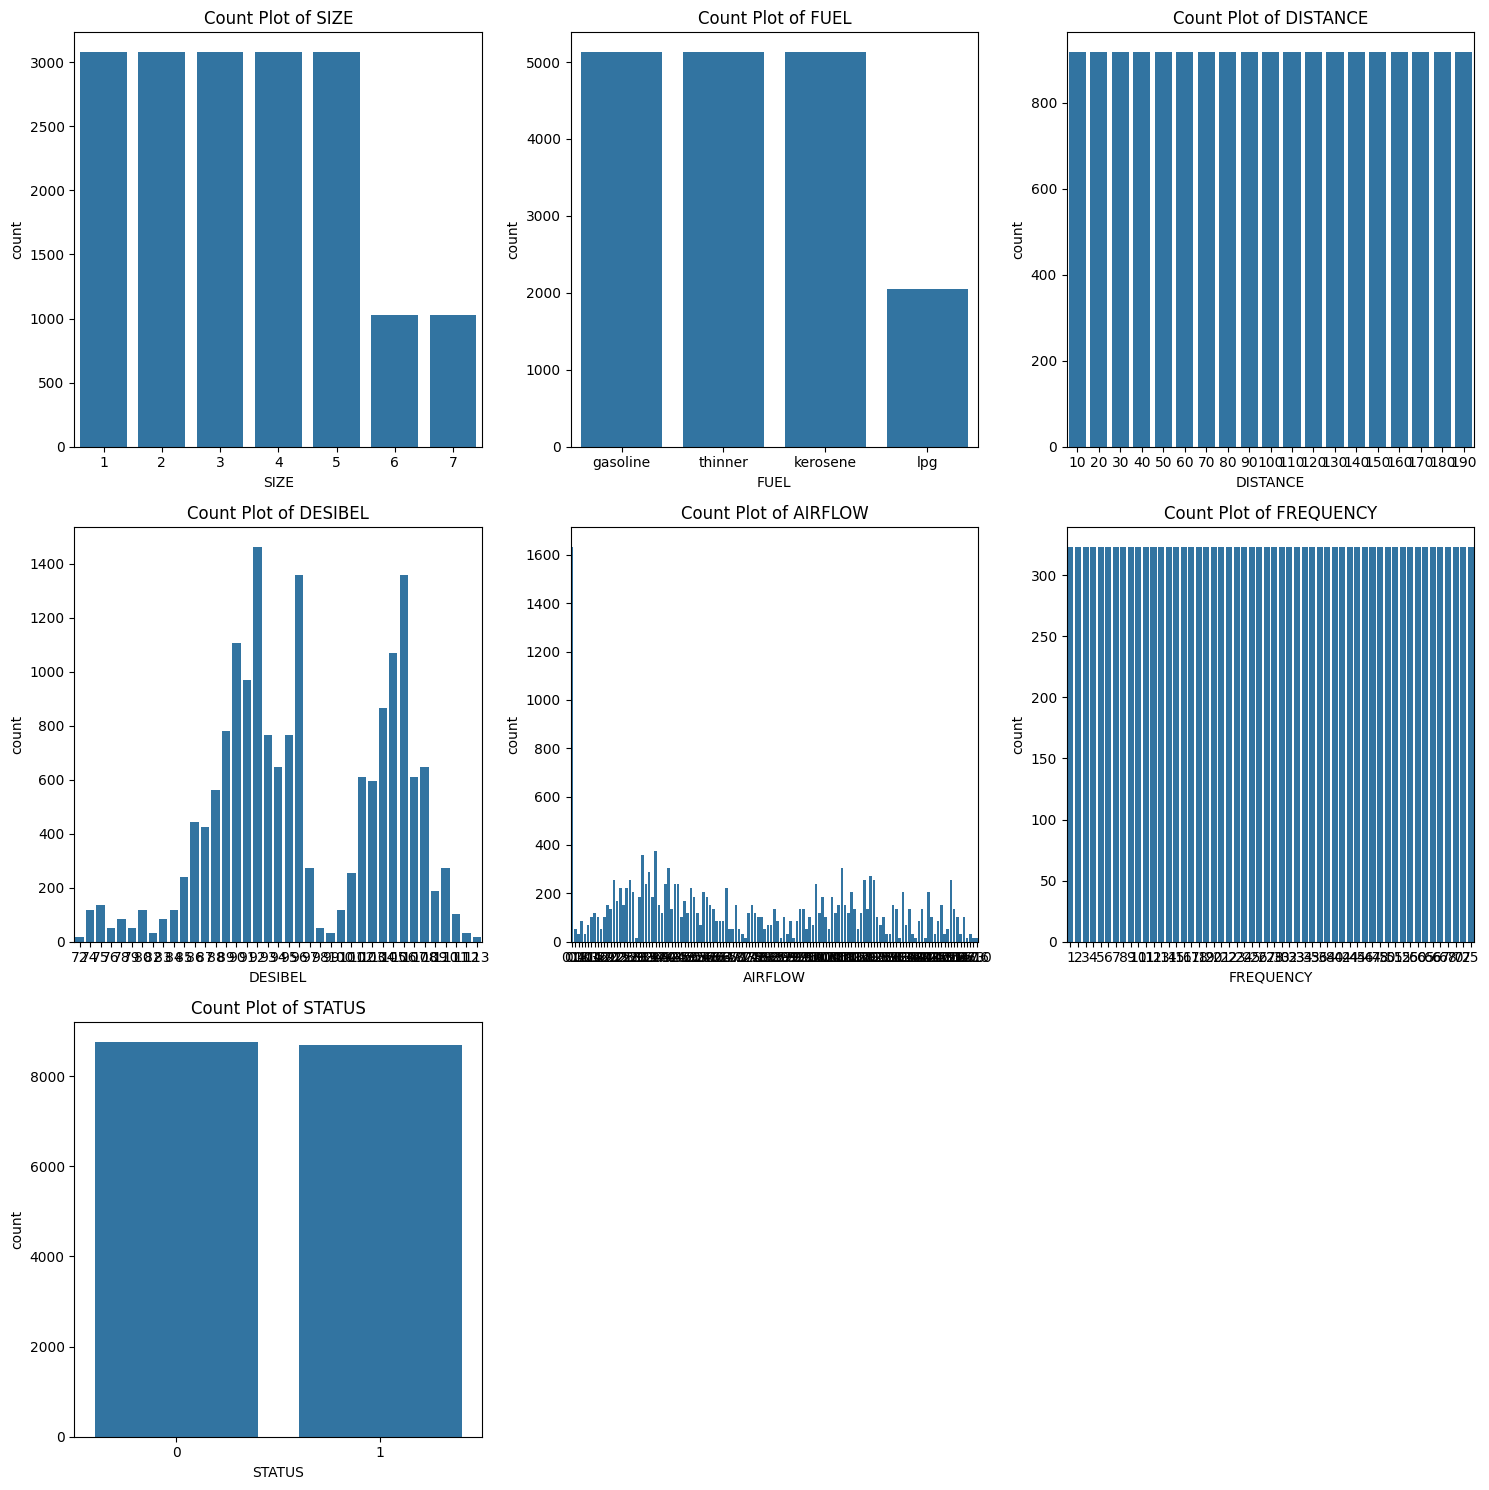

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure
fig = plt.figure(figsize=(15, 15))  # Adjust the figure size as needed

# Iterate over each column and create a count plot in a subplot
for i, col in enumerate(observations.columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=observations)
    plt.title(f'Count Plot of {col}')

# Show the plot
plt.tight_layout()
plt.show()

### Pré-traitement des données

#### Fonctions d'encodage<br>
Encodage de Fuel et une autre qui remplace size par sa valeur réelle

In [268]:
def replace_size(data):
    return data["SIZE"].map({1: 7, 2: 12, 3: 14, 4: 16, 5: 20, 6: 0, 7: 1}).to_frame()

#Encodage fuel
def replace_fuel(data):
    return data["FUEL"].map({"gasoline": 0, "thinner": 1, "kerosene": 2, "lpg": 3}).to_frame()

observations["SIZE"] = replace_size(observations)
observations["FUEL"] = replace_fuel(observations)

#### Encodage de la colonne fuel (Chaque fuel recoit un numero) <br>
avec la methode predefinie de sklearn

In [270]:
# # Methode predefinie dans SK-learn mais on ne sait pas quel variable correspont a quel numero
# from sklearn.preprocessing import LabelEncoder

# encoder = LabelEncoder()
# observations['FUEL'] = encoder.fit_transform(observations['FUEL'])

In [271]:
# Verification
observations["FUEL"].value_counts()

,count
FUEL,
0,5130
1,5130
2,5130
3,2052


### Preparation et split de données

In [272]:
from sklearn.model_selection import train_test_split

X = observations.drop(columns=['STATUS'])
Y = observations['STATUS']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=1)

## Apprentissage

### Apprentissage des modeles

#### Importation des bibliotheques

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np

#### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

# Fit the model
nb_model.fit(X_train, y_train)

predictions = nb_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(predictions, y_test)
print('Naive Bayes Model Accuracy: ' + str(accuracy))

Naive Bayes Model Accuracy: 0.8675838349097162


#### K Plus Proches Voisins (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

parameters = {'n_neighbors':[2,3,4,5,6,7]}

#Fit the model
model = GridSearchCV(knn, parameters, cv=5)
model.fit(X_train,y_train)

print (model.best_params_)
best_nb_voisins=model.best_params_['n_neighbors']
knn=KNeighborsClassifier(best_nb_voisins)
knn.fit(X_train,y_train)
prediction=knn.predict(X_test)
print('K Plus Proches Voisins avec C optimal (accuracy): '+str(accuracy_score(prediction,y_test)))

{'n_neighbors': 7}
K Plus Proches Voisins avec C optimal (accuracy): 0.9294926913155632


#### Arbre de decision (Decision Tree Classifier)

In [311]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Definition des parametres de GridSearchCV
parameters = {'criterion':["entropy","gini"]}
# Create decision tree classifer object
clf = DecisionTreeClassifier(random_state=0)
model = GridSearchCV(clf, parameters, cv=5)
model.fit(X_train,y_train)

print ("Best param is:", model.best_params_)
best_criterion=model.best_params_['criterion']

# Train model with best param
clf = DecisionTreeClassifier(criterion = best_criterion, random_state=42)
model = clf.fit(X_train,y_train)


prediction=clf.predict(X_test)
print('Decision Tree Classifier (Accuracy) : '+str(accuracy_score(prediction,y_test)))

Best param is: {'criterion': 'entropy'}
Decision Tree Classifier (Accuracy) : 0.9635998853539696


#### Foret Aleatoire (Random Forest)

In [312]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Definition des parametres de GridSearchCV
parameters = {'n_estimators':[100,150,200,250],'criterion':["entropy","gini"]}

clf = RandomForestClassifier(random_state=0)
model = GridSearchCV(clf, parameters, cv=5)
model.fit(X_train,y_train)

print ("Best param is:", model.best_params_)
best_number_trees=model.best_params_['n_estimators']
best_forest_criterion=model.best_params_['criterion']

clf = RandomForestClassifier(n_estimators=best_number_trees, criterion=best_forest_criterion, random_state=42)
# Train model
model = clf.fit(X_train,y_train)

prediction=clf.predict(X_test)
print('Random Forest Classifier (Accuracy) : '+str(accuracy_score(prediction,y_test)))

Best param is: {'criterion': 'entropy', 'n_estimators': 150}
Random Forest Classifier (Accuracy) : 0.9578675838349097


#### Gradient Boosting

In [314]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gradientBoosting=GradientBoostingClassifier()
gradientBoosting.fit(X_train,y_train)
prediction=gradientBoosting.predict(X_test)
print('Gradient Boosting : '+str(accuracy_score(prediction,y_test)))

Gradient Boosting : 0.944396675265119


#### XGBoost

In [ ]:
import pandas as pd
#from sklearn.preprocessing import MinMaxScaler
! pip install -q xgboost
import xgboost as xgb

Xboost = xgb.XGBClassifier()
Xboost.fit(X_train,y_train)
prediction=Xboost.predict(X_test)
print('Extreme Gradient Boosting : '+ str(accuracy_score(prediction,y_test)))

Extreme Gradient Boosting : 0.9776440240756664


##### Determiner les features les plus importants selon XGBoost

<Axes: ylabel='Feature_name'>

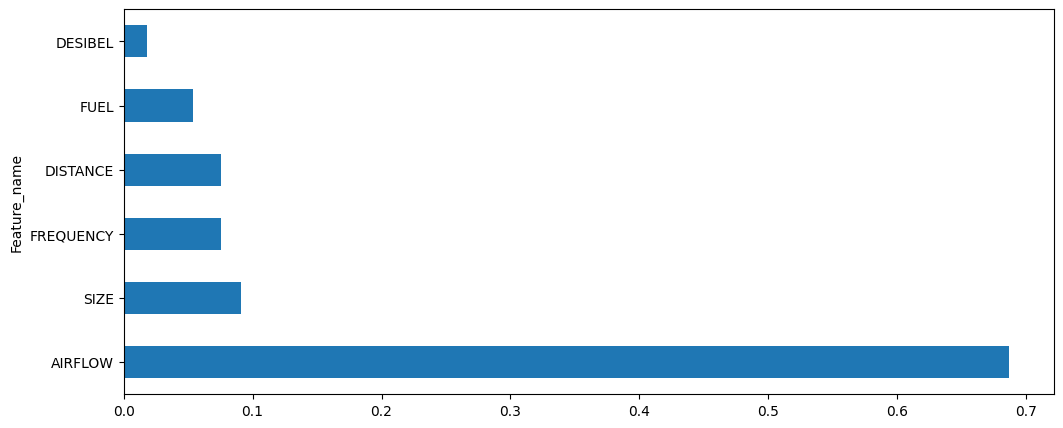

In [ ]:
type(Xboost.feature_importances_)
df=pd.DataFrame([observations.drop('STATUS', axis = 1).columns.values,list(Xboost.feature_importances_)]).T
df.columns=['Feature_name','Feature_score']
df.sort_values('Feature_score',ascending=False,inplace=True)
df.set_index('Feature_name',inplace=True)
df.iloc[:10].plot(kind='barh',legend=False,figsize=(12,5))

#### Perceptron

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron(tol=1e-3, random_state=0)
perceptron.fit(X_train,y_train)
prediction=perceptron.predict(X_test)
print('Perceptron (accuracy): '+str(accuracy_score(prediction,y_test)))
F1=f1_score(y_test,prediction)
print('F1 :'+str(F1))

Perceptron (accuracy): 0.8882201203783319
F1 :0.8808068459657702


#### Logistic Regression

In [ ]:
#regression logistique
from sklearn.linear_model import LogisticRegression
regression_logistique=LogisticRegression()
regression_logistique.fit(X_train,y_train)
prediction=regression_logistique.predict(X_test)
print('Regression Logistique (accuracy): '+str(accuracy_score(prediction,y_test)))
F1=f1_score(y_test,prediction)
print('F1 :'+str(F1))

Regression Logistique (accuracy): 0.8928059615935798
F1 :0.8872135102533173


#### SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# # Prends beaucoup de temps

# Cs = list(np.logspace(-3, 3, 4))
# parameters = {'kernel': ['linear','rbf','poly'], 'C': Cs}

# svm=SVC()
# model=GridSearchCV(svm, parameters, cv=2,scoring="accuracy", n_jobs=-1)
# model.fit(X_train,y_train)

# print ("Best param is:", model.best_params_)
# best_c=model.best_params_['C']
# best_kernel=model.best_params_['kernel']

best_c=1000.0
best_kernel="rbf"

svm=SVC(C=best_c, kernel=best_kernel)
svm.fit(X_train,y_train)

prediction=svm.predict(X_test)
print('Machine Vecteurs Supports  (accuracy): '+str(accuracy_score(prediction,y_test)))

Machine Vecteurs Supports  (accuracy): 0.9335053023789052


#### K-Means

##### Methode elbow <br>
pour determiner nombre optimal de clusters

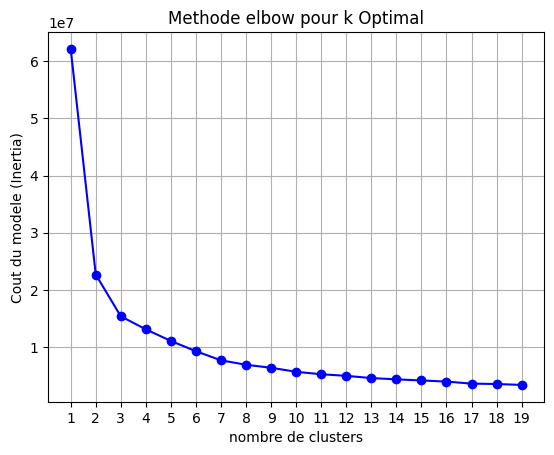

In [ ]:
inertia = []
K_range = range(1, 20)
for k in K_range:
    model = KMeans(n_clusters=k).fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('nombre de clusters')
plt.ylabel('Cout du modele (Inertia)')
plt.title('Methode elbow pour k Optimal')
plt.xticks(K_range)
plt.grid(True)

##### Apprentissage

In [329]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2, random_state=42)
model.fit(X)
clusters=model.predict(X)

model.cluster_centers_
print(model.inertia_)

22683990.946197268


##### Visualisation 2D

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


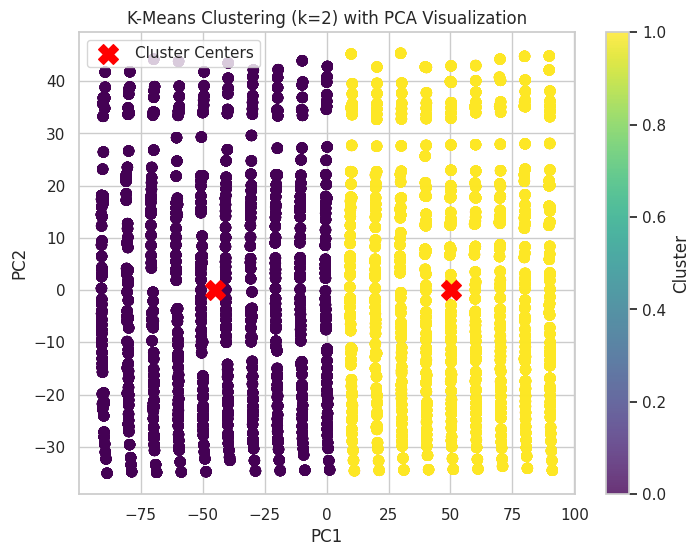

In [330]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualize the clusters in the PCA-reduced space
plt.figure(figsize=(8, 6))

# Plot
scatter=plt.scatter(X_pca[:, 0], X_pca[:, 1],c=clusters, cmap='viridis', s=50, alpha=0.8)
# Add cluster centers to the plot
centers_pca = pca.transform(model.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
# Plot title and labels
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization')
plt.title(f'K-Means Clustering (k=2) with PCA Visualization')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True)
plt.show()

##### Visualisation 3D

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


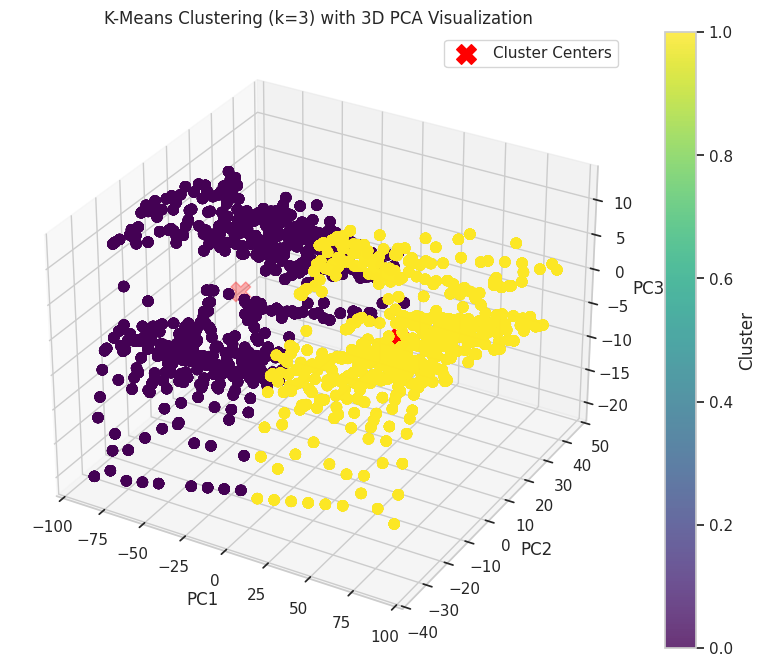

In [331]:
from mpl_toolkits.mplot3d import Axes3D

# Reduce to 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=clusters, cmap='viridis', s=50, alpha=0.8)

# Add cluster centers
centers_pca = pca.transform(model.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], centers_pca[:, 2], c='red', marker='X', s=200, label='Cluster Centers')

# Add labels and title
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'K-Means Clustering (k=3) with 3D PCA Visualization')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

### Comparaison de performances de classifieurs

#### Preparation des fonctions et classes

In [332]:
from tabulate import tabulate

# Liste des classifieurs évalués
classifiers = [
    ('Naive Bayes Classifier', GaussianNB()),
    ('KNeighbors Classifier',KNeighborsClassifier(best_nb_voisins)),
    ('Decision Tree Classifier',DecisionTreeClassifier(criterion = best_criterion, random_state=42)),
    ('Random Forest Classifier',RandomForestClassifier(n_estimators=best_number_trees, criterion=best_forest_criterion, random_state=42)),
    ('Gradient Boosting Classifier',GradientBoostingClassifier()),
    ('Extreme Gradient Boosting',xgb.XGBClassifier()),
    ('Perceptron',Perceptron()),
    ('Logistic Regression',LogisticRegression()),
    ('Support Vector Machine',SVC(C=best_c, kernel=best_kernel))
    ]

modeles = [
    ('KMeans', 'Unsupervised'),
    ('KNeighbors Classifier', 'Supervised'),
    ('Decision Tree Classifier', 'Supervised'),
    ('Random Forest Classifier', 'Supervised'),
    ('Gradient Boosting Classifier', 'Supervised'),
    ('Extreme Gradient Boosting', 'Supervised'),
    ('Perceptron', 'Supervised'),
    ('Logistic Regression', 'Supervised'),
    ('Support Vector Machine', 'Supervised'),
    ('Naive Bayes Classifier', 'Supervised'),
]

classifier_info = pd.DataFrame(modeles, columns=['Classifier Name', 'Model Type'])
print(tabulate(classifier_info, headers='keys', tablefmt='rounded_grid'))

╭────┬──────────────────────────────┬──────────────╮
│    │ Classifier Name              │ Model Type   │
├────┼──────────────────────────────┼──────────────┤
│  0 │ KMeans                       │ Unsupervised │
├────┼──────────────────────────────┼──────────────┤
│  1 │ KNeighbors Classifier        │ Supervised   │
├────┼──────────────────────────────┼──────────────┤
│  2 │ Decision Tree Classifier     │ Supervised   │
├────┼──────────────────────────────┼──────────────┤
│  3 │ Random Forest Classifier     │ Supervised   │
├────┼──────────────────────────────┼──────────────┤
│  4 │ Gradient Boosting Classifier │ Supervised   │
├────┼──────────────────────────────┼──────────────┤
│  5 │ Extreme Gradient Boosting    │ Supervised   │
├────┼──────────────────────────────┼──────────────┤
│  6 │ Perceptron                   │ Supervised   │
├────┼──────────────────────────────┼──────────────┤
│  7 │ Logistic Regression          │ Supervised   │
├────┼──────────────────────────────┼─────────

In [333]:
import pandas as pd        # charge un package pour le traitement des données
from sklearn.metrics import confusion_matrix

# Definition des métriques de performance
def perf_compute(clf, name):
    """
    Calcule le temps d'apprentissage, de prediction, le score
    et la matrice de confusion d'un classifieur
    """
    # On initialise le conteneur
    perf = pd.Series(name=name)
    # On crée les callables qu'on passera à la fonction de profiling
    fit = lambda: clf.fit(X_train, y_train)
    score = lambda: clf.score(X_test, y_test)

    # On entraîne le modèle et on fait des prédictions
    clf_fitted = fit()
    y_pred = clf_fitted.predict(X_test)

    # On calcule le score en pourcentage
    perf['score'] = clf_fitted.score(X_test, y_test) * 100

    # On calcule la matrice de confusion
    perf['conf_mat'] = [confusion_matrix(y_test, y_pred)]

    # On calcule la précision, le rappel et le F1-score
    perf['precision'] = precision_score(y_test, y_pred, average='weighted') * 100
    perf['recall'] = recall_score(y_test, y_pred, average='weighted') * 100
    perf['f1_score'] = f1_score(y_test, y_pred, average='weighted') * 100

    return perf

In [334]:
# On lance le calcule de performance
perfs = pd.DataFrame([perf_compute(clf, name) for name, clf in classifiers])
perfs = perfs.sort_values('score')

perfs[['score']].T

,Naive Bayes Classifier,Perceptron,Logistic Regression,KNeighbors Classifier,Support Vector Machine,Gradient Boosting Classifier,Random Forest Classifier,Decision Tree Classifier,Extreme Gradient Boosting
score,86.930353,88.822012,89.280596,92.949269,93.35053,94.439668,95.786758,96.359989,97.764402


In [335]:
import seaborn as sns

def plot_conf_mat(perf, ax, title='Model'):
    """
    Affichage de la matrice de confusion
    """
    sns.heatmap(perf.conf_mat[0], ax=ax, square=True, annot=True, fmt='d')
    ax.set_title('{}: {}\nScore: {:.2f}'.format(title, perf.name, perf.score))
    ax.set_xlabel('True label')
    ax.set_ylabel('Predicted label')

#### Matrice de confusion du pire modele et meilleur modele

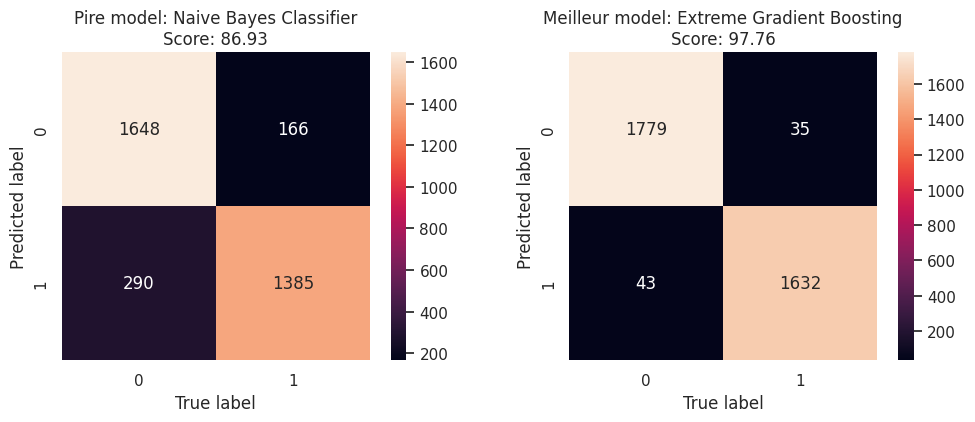

In [344]:
# Affichage du plus mauvais et du meilleur classifieur
# Les classifieurs sont classés par scores croissant
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))
plot_conf_mat(perfs.iloc[0], ax=axs[0], title='Pire model')
plot_conf_mat(perfs.iloc[-1], ax=axs[1], title='Meilleur model')

#### Matrice de confusion de tous les modeles

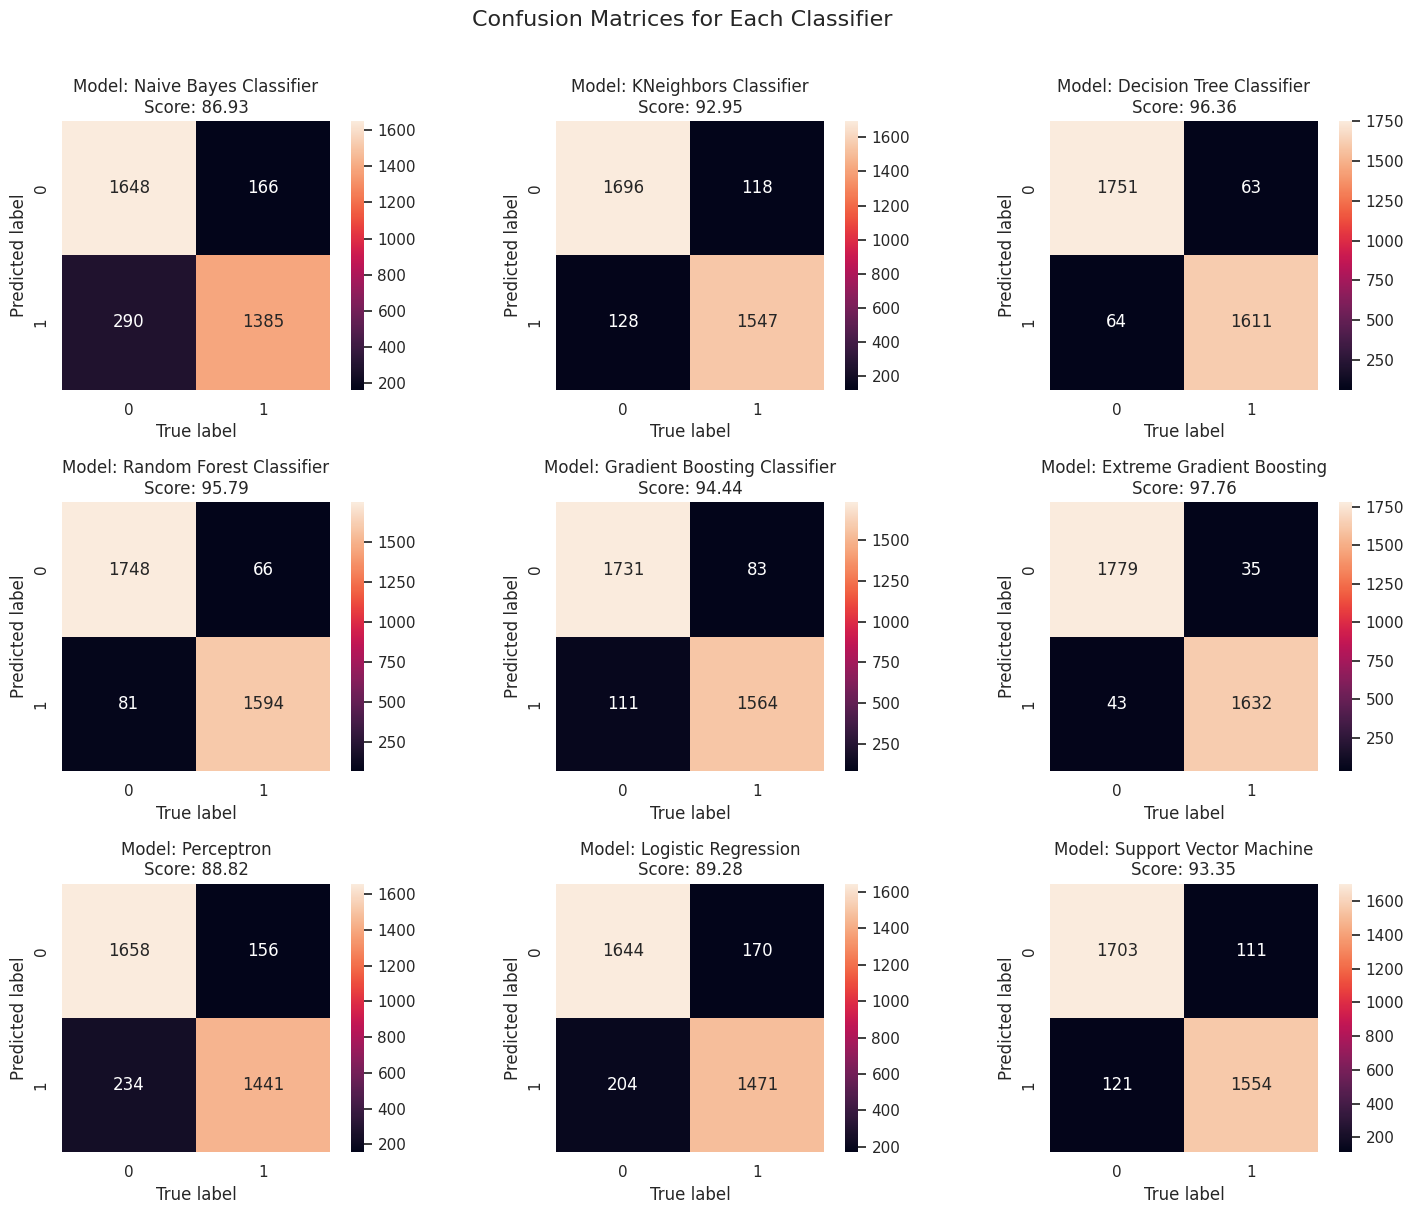

In [337]:
import seaborn as sns

metrics_list = []

num_classifiers = len(classifiers)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle("Confusion Matrices for Each Classifier", fontsize=16, y=1.01)
axes = axes.flatten()

# Evaluate each classifier
for idx, (name, classifier) in enumerate(classifiers):
    perf = perf_compute(classifier, name)

    # Append metrics to the list
    metrics_list.append({
        'Classifier': name,
        'Precision': perf['precision'],
        'Recall': perf['recall'],
        'F1-Score': perf['f1_score'],
        'Accuracy': perf['score'],
        'Confusion Matrix': perf['conf_mat'][0]
    })

    # Plot confusion matrix using plot_conf_mat
    plot_conf_mat(perf, ax=axes[idx])

plt.tight_layout()
plt.show()

#### Affichage de tous les metriques calculées

In [338]:
metrics_df = pd.DataFrame(metrics_list).sort_values(by='Accuracy', ascending=False)
metrics_df.drop(columns=["Confusion Matrix"])

,Classifier,Precision,Recall,F1-Score,Accuracy
5,Extreme Gradient Boosting,97.765000,97.764402,97.764186,97.764402
2,Decision Tree Classifier,96.359921,96.359989,96.359947,96.359989
3,Random Forest Classifier,95.788705,95.786758,95.785957,95.786758
4,Gradient Boosting Classifier,94.447585,94.439668,94.437527,94.439668
8,Support Vector Machine,93.350436,93.350530,93.349715,93.350530
1,KNeighbors Classifier,92.949070,92.949269,92.948405,92.949269
7,Logistic Regression,89.287217,89.280596,89.275404,89.280596
6,Perceptron,88.880127,88.822012,88.806409,88.822012
0,Naive Bayes Classifier,87.081793,86.930353,86.895139,86.930353


#### Affichage des metriques dans un plot

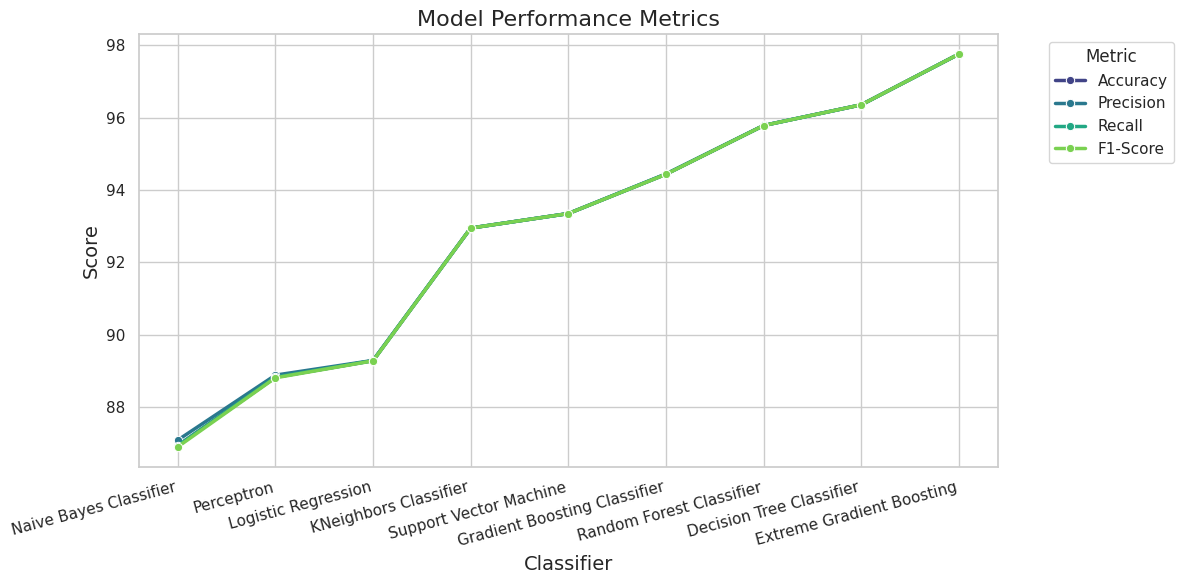

In [339]:
# Set the style for the plot
sns.set(style="whitegrid")

# Melt the DataFrame to long format for easier plotting
metrics_long = metrics_df.sort_values(by='Accuracy', ascending=True).melt(id_vars=['Classifier'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                               var_name='Metric', value_name='Score')

# Create a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Classifier', y='Score', hue='Metric', data=metrics_long, marker='o', palette='viridis', linewidth=2.5)

# Add labels and title
plt.title('Model Performance Metrics', fontsize=16)
plt.xlabel('Classifier', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=15, ha='right')  # Rotate x-axis labels for better readability
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

## Enregistrement du modele

In [ ]:
import pickle

# Save the pipeline to a pickle file
with open('pipeline.pkl', 'wb') as f:
    pickle.dump(model, f)

## Chargement du modele

In [ ]:
with open('pipeline.pkl', 'rb') as f:
    model = pickle.load(f)